# Dataset exploration

You will classify the species in a camera-trap photograph, and you will be scored on
**48 camera deployments that never appear in training**. This notebook is the first thing
to run. It trains nothing: it reads the metadata for every image, shows you some of the
images themselves, and ends on one figure worth looking at properly.

Under a minute on a laptop, no GPU, and it doubles as a tour of `iwildcam.data` and
`iwildcam.data`.

**Where the numbers come from.** Anything computed from `task.df` covers all 201,399
images and is exact. The figures need actual pixels, so they read whichever of `data/images_h448/` or
`data/images_h224/` you built.
This notebook was executed on a **4,228-image sample** rather than the full 85 GB
download, so anything marked *(sample)* is illustrative and will move when you re-run it
on the whole set. Every image shown is a real, unedited frame.

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from iwildcam.data import (load_task, load_fold, load_taxonomy, image_dir_for,
                           official_test_cameras)


plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# require_files=False: the class set is decided from the metadata, never from what
# happens to be on your disk.
task = load_task(require_files=False)

# The images are a plain folder of JPEGs named by `file_name` -- that is the whole
# storage contract, so reading one is just `Image.open`.
# 448 if you built it (the banner strip near the end is worth the pixels), else 224.
IMAGES = next((d for d in map(image_dir_for, (448, 224)) if d.exists()), image_dir_for())
have = {f.name for f in IMAGES.iterdir()} if IMAGES.exists() else set()

def show(name):
    if name not in have:
        raise FileNotFoundError(
            f"{name} is not in {IMAGES.name}. The figures below use fixed file names, so "
            f"they need a finished `prepare.py` run, not a partial one.")
    return Image.open(IMAGES / name)

df = task.df.copy()
df["hour"] = df["datetime"].dt.hour
df["night"] = (df["hour"] >= 18) | (df["hour"] < 6)
avail = df[df["file_name"].isin(have)]

print(task.summary())
print(f"\nheld-out cameras in the official protocol : {len(official_test_cameras())}")
print(f"images in your image folder               : {len(have):,} "
      f"({len(avail):,} of them labelled)")

127,681 labelled images, 60 species, 294 cameras, 9,653 bursts; 69,469 unlabelled empty frames from 265 cameras

held-out cameras in the official protocol : 48
images in your image folder               : 201,399 (127,681 of them labelled)


## 1. What one image actually is

A motion sensor fires and the camera takes a photograph of whatever walked past. Nobody
framed the shot. The animal can be centred and filling the frame, or a smudge at the edge
of a very dark one, and both carry the same species label.

Four daytime frames on the top row, four night-time frames on the bottom.

original pixel sizes of these eight frames:
width  height
1920   1080      7
1280   1024      1


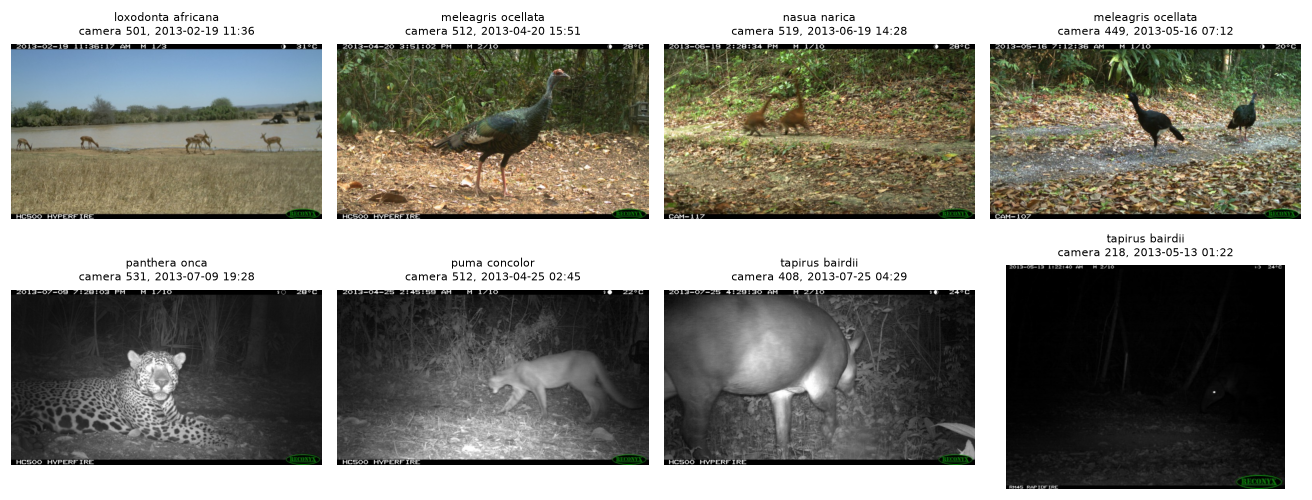

In [3]:
# Fixed file names, so this figure is the same for everyone.
SHOWCASE = [
    "8f50c46e-21bc-11ea-a13a-137349068a90.jpg",   # camera 501
    "93968b44-21bc-11ea-a13a-137349068a90.jpg",   # camera 512
    "9723f986-21bc-11ea-a13a-137349068a90.jpg",   # camera 519
    "8c963b50-21bc-11ea-a13a-137349068a90.jpg",   # camera 449
    "8f3d42c2-21bc-11ea-a13a-137349068a90.jpg",   # camera 531
    "88b8528e-21bc-11ea-a13a-137349068a90.jpg",   # camera 512
    "8bceb9f4-21bc-11ea-a13a-137349068a90.jpg",   # camera 408
    "90830b26-21bc-11ea-a13a-137349068a90.jpg",   # camera 218
]
meta = df.set_index("file_name")

fig, axes = plt.subplots(2, 4, figsize=(12, 4.6))
for ax, name in zip(axes.ravel(), SHOWCASE):
    r = meta.loc[name]
    ax.imshow(show(name))
    ax.set_title(f"{r.category}\ncamera {r.location}, {r.datetime:%Y-%m-%d %H:%M}",
                 fontsize=7.5)
    ax.axis("off")
plt.tight_layout()

print("original pixel sizes of these eight frames:")
print(meta.loc[SHOWCASE, ["width", "height"]].value_counts().to_string())

## 2. Sixty species, and most of them are rare

`load_task` keeps a species only if at least 5 different cameras saw it at least 10 times
each. That leaves 60 species. It does not leave them balanced.

The second panel is the one to read. **A species seen at three cameras cannot teach a
model anything general about that species — only about those three backgrounds**, and
eleven of the sixty species are in that position.

most common  : meleagris ocellata       16,242 images (12.7% of the data)
rarest       : puma yagoroundi              90 images
median species                                    943 images
top 5 species, out of 60                        39.3% of the data
bottom 30 species, out of 60                     9.4% of the data
median cameras a species is seen at                24
species seen at 10 cameras or fewer                11

taxonomy.csv: 54 genera, 30 families, 11 orders  ->  a coarser label is one join away


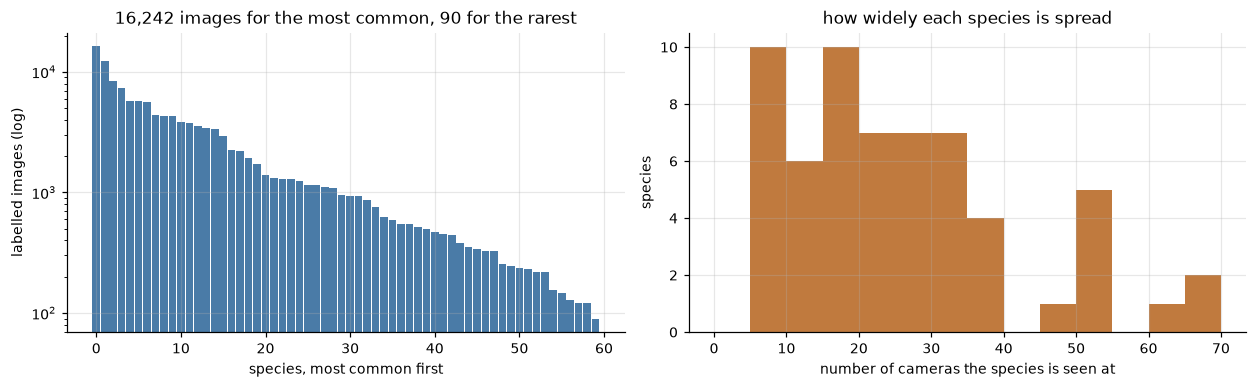

In [4]:
counts = df["category"].value_counts()
per_camera = (pd.crosstab(df["category"], df["location"]) > 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].bar(range(len(counts)), counts.to_numpy(), color="#4a7ba7", width=0.9)
axes[0].set_yscale("log")
axes[0].set_xlabel("species, most common first")
axes[0].set_ylabel("labelled images (log)")
axes[0].set_title(f"{counts.iloc[0]:,} images for the most common, "
                  f"{counts.iloc[-1]} for the rarest")

axes[1].hist(per_camera.to_numpy(), bins=np.arange(0, per_camera.max() + 6, 5),
             color="#c07a3e")
axes[1].set_xlabel("number of cameras the species is seen at")
axes[1].set_ylabel("species")
axes[1].set_title("how widely each species is spread")
plt.tight_layout()

print(f"most common  : {counts.index[0]:24s} {counts.iloc[0]:6,d} images "
      f"({counts.iloc[0] / len(df):.1%} of the data)")
print(f"rarest       : {counts.index[-1]:24s} {counts.iloc[-1]:6,d} images")
print(f"median species                                 {counts.median():6,.0f} images")
print(f"top 5 species, out of 60                       {counts.head(5).sum() / len(df):6.1%} "
      f"of the data")
print(f"bottom 30 species, out of 60                   {counts.tail(30).sum() / len(df):6.1%} "
      f"of the data")
print(f"median cameras a species is seen at            {per_camera.median():6.0f}")
print(f"species seen at 10 cameras or fewer            {(per_camera <= 10).sum():6d}")

tax = load_taxonomy()
print(f"\ntaxonomy.csv: {tax['genus'].nunique()} genera, {tax['family'].nunique()} families, "
      f"{tax['order'].nunique()} orders  ->  a coarser label is one join away")

## 3. A quarter of the frames are infrared, not colour

After dark the camera switches to an infrared flash and the image comes back grey. This is
the largest single visual change in the dataset, it is free to detect from the timestamp,
and — unlike the camera itself — **it varies inside almost every deployment**. The median
camera is a bit over a quarter infrared: two visual domains wearing one label.

The clock is only a proxy. Under a forest canopy the flash also fires at eight in the
morning, which is why the right-hand panel does not drop to zero in daylight.

all 201,399 images, taken 18:00-06:00       25.3%
median camera, share of night images         28.1%
cameras with both day and night frames       116 of 122

(sample) night frames that are effectively grey   86.7%
(sample) day frames that are effectively grey     48.7%


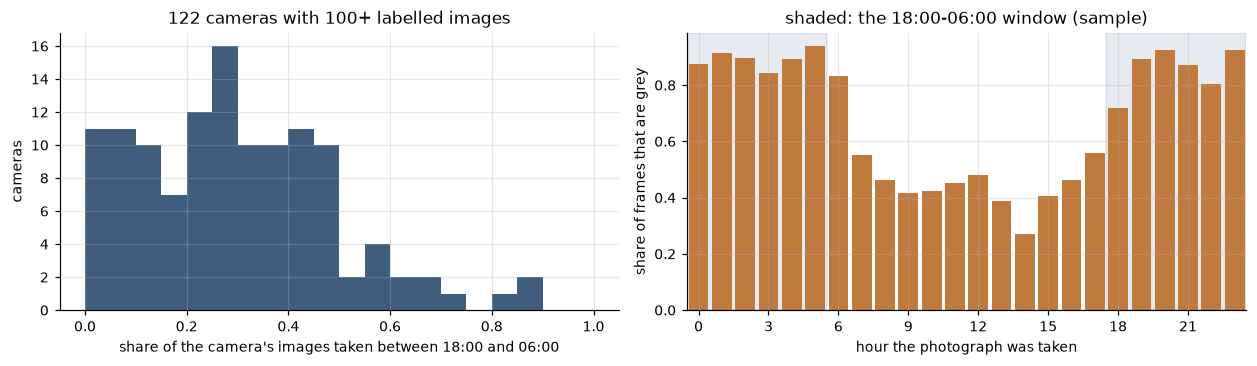

In [5]:
by_camera = df.groupby("location").agg(n=("file_name", "size"), night=("night", "mean"))
big = by_camera[by_camera["n"] >= 100]

# Colour or grey? Mean spread between the R, G and B channels of each image.
def capped(frame, column, n):
    """At most n rows per value of `column`, chosen the same way every run."""
    return pd.concat([g if len(g) <= n else g.sample(n, random_state=0)
                      for _, g in frame.groupby(column)])

sample = capped(avail, "location", 40)
spread = np.array([np.ptp(np.asarray(show(n).convert("RGB").resize((32, 32)),
                                     dtype=np.int16), axis=2).mean()
                   for n in sample["file_name"]])
is_night = sample["night"].to_numpy()
grey = pd.Series(spread < 6, index=sample.index).groupby(sample["hour"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].hist(big["night"].to_numpy(), bins=np.arange(0, 1.02, 0.05), color="#3f5d7d")
axes[0].set_xlabel("share of the camera's images taken between 18:00 and 06:00")
axes[0].set_ylabel("cameras")
axes[0].set_title(f"{len(big)} cameras with 100+ labelled images")

axes[1].axvspan(-0.5, 5.5, color="#3f5d7d", alpha=0.12)
axes[1].axvspan(17.5, 23.5, color="#3f5d7d", alpha=0.12)
axes[1].bar(grey.index, grey.to_numpy(), color="#c07a3e", width=0.85)
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_xlim(-0.5, 23.5)
axes[1].set_xlabel("hour the photograph was taken")
axes[1].set_ylabel("share of frames that are grey")
axes[1].set_title("shaded: the 18:00-06:00 window (sample)")
plt.tight_layout()

# Straight from the parquet, not from `task`: this one covers the empty frames and the
# dropped non-species categories too, so it is every image in the release.
full = pd.read_csv("../data/metadata.csv.gz", parse_dates=["datetime"])
night_all = ((full["datetime"].dt.hour >= 18) | (full["datetime"].dt.hour < 6)).mean()
print(f"all {len(full):,} images, taken 18:00-06:00      {night_all:6.1%}")
print(f"median camera, share of night images        {big['night'].median():6.1%}")
print(f"cameras with both day and night frames      {((big['night'] > 0) & (big['night'] < 1)).sum():4d} "
      f"of {len(big)}")
print(f"\n(sample) night frames that are effectively grey  "
      f"{(spread[is_night] < 6).mean():6.1%}")
print(f"(sample) day frames that are effectively grey    "
      f"{(spread[~is_night] < 6).mean():6.1%}")

## 4. The images arrive in bursts, not one at a time

One trigger fires a run of frames a second or two apart. Consecutive frames share the
background, the lighting and usually the animal, so they are near-duplicates of each
other. Every image carries a `burst_id` saying which burst it belongs to, and **a burst,
not an image, is the smallest thing a split may move.**

Look at the first two frames below. The deer is a smudge at the left edge, or not there at
all, and they carry the species label anyway, because labels were assigned to whole
sequences.

burst groups over the 127,681 labelled images   9,653
median burst                                    10 frames
largest burst                                   825 frames
images sitting in a burst of 2 or more          99.5%

Both shipped splits move whole bursts. That is what `split_by_burst` is for.


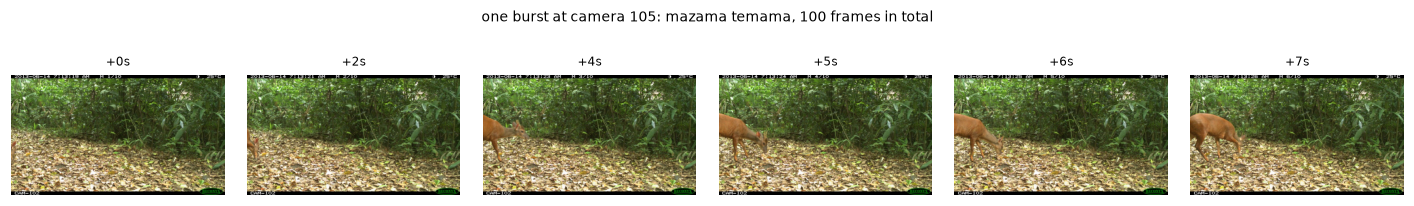

In [6]:
BURST = "s:301b8f1e-7d42-11eb-8fb5-0242ac1c0002"          # camera 105, one trigger
frames = df[df["burst_id"] == BURST].sort_values("datetime")
frames = frames[frames["file_name"].isin(have)].head(6)
t0 = frames["datetime"].iloc[0]

fig, axes = plt.subplots(1, len(frames), figsize=(13, 1.85))
for ax, (_, r) in zip(axes, frames.iterrows()):
    ax.imshow(show(r.file_name))
    ax.set_title(f"+{(r.datetime - t0).total_seconds():.0f}s", fontsize=8)
    ax.axis("off")
fig.suptitle(f"one burst at camera {frames['location'].iloc[0]}: "
             f"{frames['category'].iloc[0]}, {len(df[df['burst_id'] == BURST])} frames "
             f"in total", fontsize=9)
plt.tight_layout(rect=(0, 0, 1, 0.88))

sizes = df.groupby("burst_id").size()
print(f"burst groups over the {len(df):,} labelled images   {len(sizes):,}")
print(f"median burst                                    {sizes.median():.0f} frames")
print(f"largest burst                                   {sizes.max():,} frames")
print(f"images sitting in a burst of 2 or more          "
      f"{sizes[sizes >= 2].sum() / len(df):.1%}")
print("\nBoth shipped splits move whole bursts. That is what `split_by_burst` is for.")

## 5. Now the part you are being scored on

Here is one species, *crax rubra*, the great curassow, at six cameras. The top row is
three cameras whose images the model trains on. The bottom row is three of the 48 it never
sees until the test.

The bird is the label. **Everything else in the frame — the leaf litter, the trees, the
angle, the exposure, whether the flash fired — belongs to the camera**, and all of it
changes between the two rows.

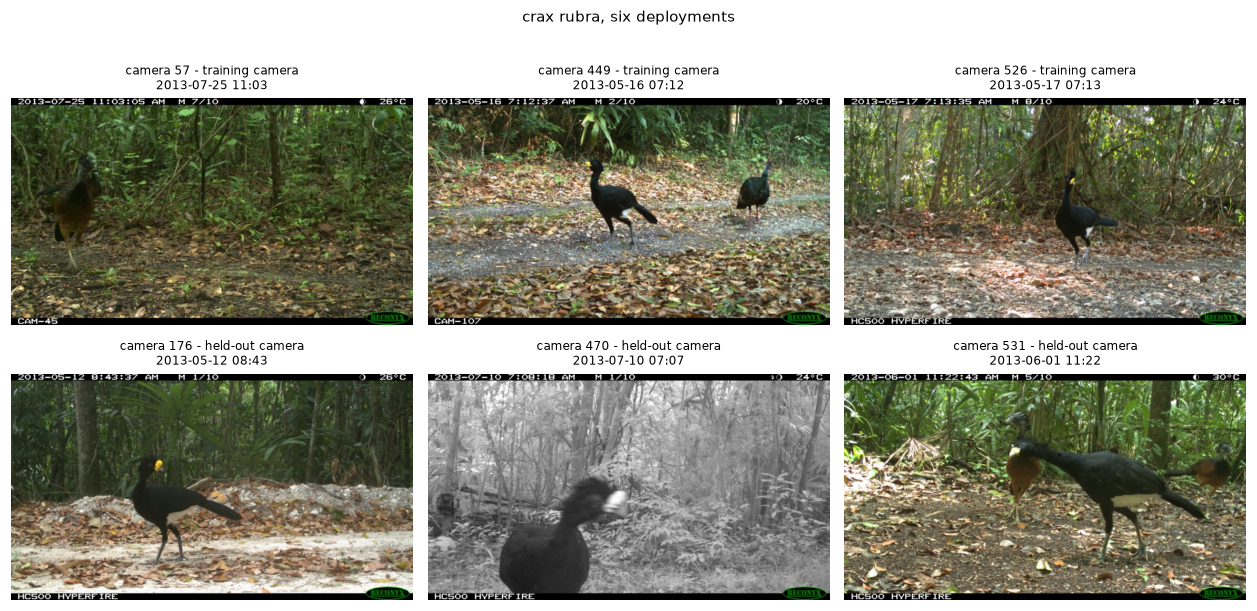

In [7]:
SAME_SPECIES = [
    ("873895a4-21bc-11ea-a13a-137349068a90.jpg", "training camera"),
    ("94d19760-21bc-11ea-a13a-137349068a90.jpg", "training camera"),
    ("9933d4e4-21bc-11ea-a13a-137349068a90.jpg", "training camera"),
    ("950355a2-21bc-11ea-a13a-137349068a90.jpg", "held-out camera"),
    ("97e3f34e-21bc-11ea-a13a-137349068a90.jpg", "held-out camera"),
    ("892c315e-21bc-11ea-a13a-137349068a90.jpg", "held-out camera"),
]
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.8))
for ax, (name, role) in zip(axes.ravel(), SAME_SPECIES):
    r = meta.loc[name]
    ax.imshow(show(name))
    ax.set_title(f"camera {r.location} - {role}\n{r.datetime:%Y-%m-%d %H:%M}", fontsize=8)
    ax.axis("off")
fig.suptitle("crax rubra, six deployments", fontsize=10)
plt.tight_layout(rect=(0, 0, 1, 0.95), h_pad=2.5)

Nothing subtle is going on. Reduce those photographs to 16x16 thumbnails, throw away the
species entirely, and ask a plain question: for each image, which *other* image in the set
does it sit closest to in raw pixels? Bursts are excluded from their own answer, so this
is never a near-duplicate matching itself.

In [8]:
top = avail["location"].value_counts().head(15).index
pool = capped(avail[avail["location"].isin(top)], "location", 220).reset_index(drop=True)

thumb = np.stack([np.asarray(show(n).convert("RGB").resize((16, 16), Image.BILINEAR),
                             dtype=np.float32).ravel() / 255 for n in pool["file_name"]])
thumb -= thumb.mean(axis=0)

sq = (thumb ** 2).sum(axis=1)
dist = sq[:, None] + sq[None, :] - 2 * thumb @ thumb.T
burst = pd.factorize(pool["burst_id"])[0]
dist[burst[:, None] == burst[None, :]] = np.inf        # never match inside a burst
nearest = dist.argmin(axis=1)

cam = pool["location"].to_numpy()
sp = pool["category"].to_numpy()
p_cam = (pool["location"].value_counts(normalize=True) ** 2).sum()
p_sp = (pool["category"].value_counts(normalize=True) ** 2).sum()

print(f"(sample) {len(pool):,} images from the {pool['location'].nunique()} best-covered "
      f"cameras, {pool['category'].nunique()} species\n")
print(f"{'':38s} {'found':>7s} {'by chance':>10s}")
print(f"{'nearest image shares the CAMERA':38s} {(cam[nearest] == cam).mean():7.1%} "
      f"{p_cam:10.1%}")
print(f"{'nearest image shares the SPECIES':38s} {(sp[nearest] == sp).mean():7.1%} "
      f"{p_sp:10.1%}")

(sample) 3,300 images from the 15 best-covered cameras, 37 species

                                         found  by chance
nearest image shares the CAMERA          84.9%       6.7%
nearest image shares the SPECIES         39.6%      12.3%


**Raw pixel similarity tracks the camera more strongly than it tracks the animal.** A
model trained to minimise loss on the training cameras has every reason to use that, and
nothing in the loss tells it not to.

## 6. OOD performance degradation

`official_ood` is the protocol. It holds out whole cameras: no image from a test camera
appears in training, and validation is a further set of cameras, so model selection also
sees a real deployment shift. Both folds ship as columns of the metadata, so everyone gets
the same partition however much of the archive they have prepared.

In [9]:
fold = load_fold(task, "official_ood")
for name, idx in fold.items():
    print(f"{name:6s} {len(idx):7,d} images   {len(np.unique(task.camera[idx])):3d} cameras   "
          f"{len(set(task.y[idx].tolist())):2d} species")

test_cam, test_n = np.unique(task.camera[fold["test"]], return_counts=True)
order = np.argsort(-test_n)
print(f"\nspecies missing from the test cameras entirely "
      f"{task.n_classes - len(set(task.y[fold['test']].tolist())):3d} of {task.n_classes}")
print(f"share of test images at the single biggest camera ({test_cam[order[0]]})  "
      f"{test_n[order[0]] / test_n.sum():6.1%}")
print(f"share of test images at the top 10 cameras                 "
      f"{test_n[order[:10]].sum() / test_n.sum():6.1%}")
print(f"unlabelled empty frames from the held-out cameras   {len(task.empty[task.empty['location'].isin(official_test_cameras())]):,}")

print("\nWhat that costs, measured on exactly this repo (resnet50 @224, 12 epochs,")
print("three seeds - the table in the README, XXX until re-measured):")
print("\n  random_burst, same cameras      macro F1  XXX +/- XXX")
print("  official_ood, held-out cameras  macro F1  XXX +/- XXX")
print("  the gap                                   XXX")

train   85,265 images   216 cameras   60 species
val     14,652 images    32 cameras   45 species
test    27,764 images    46 cameras   57 species

species missing from the test cameras entirely   3 of 60
share of test images at the single biggest camera (501)   30.2%
share of test images at the top 10 cameras                  88.1%
unlabelled empty frames from the held-out cameras   14,106

What that costs, measured on exactly this repo (resnet50 @224, 12 epochs,
three seeds - the table in the README, XXX until re-measured):

  random_burst, same cameras      macro F1  XXX +/- XXX
  official_ood, held-out cameras  macro F1  XXX +/- XXX
  the gap                                   XXX


## 7. Camera locations (when known)

The split holds out **cameras**, not regions. This is what that looks like on the ground.

Each panel is one site, drawn in kilometres from its centre, so it is a map at true scale.
A dot is a camera, sized by how many images it contributes, and coloured by the fold its
images land in. The top row is `official_ood`, the bottom row `random_burst`.

`data/gps_locations.json` ships with the repo, but it does not cover every camera — the
gap is the subject of the next section.

cameras in the labelled task   294
  coordinates released         179   124,460 images (97.5%), median 263 per camera
  coordinates withheld         115     3,221 images ( 2.5%), median  13 per camera

of the 46 held-out cameras, 34 have coordinates. Distance from each of those
to the nearest camera the model trains on: min 0.23 km, median 1.31 km, max 8.89 km
33 of 34 are within 5 km.

official_ood  216 train only,  46 test only,  32 val only
  withheld, so absent from the map: 94 train only,  12 test only,  9 val only

random_burst  247 several folds,  37 train only,  10 test only
  withheld, so absent from the map: 83 several folds,  24 train only,  8 test only


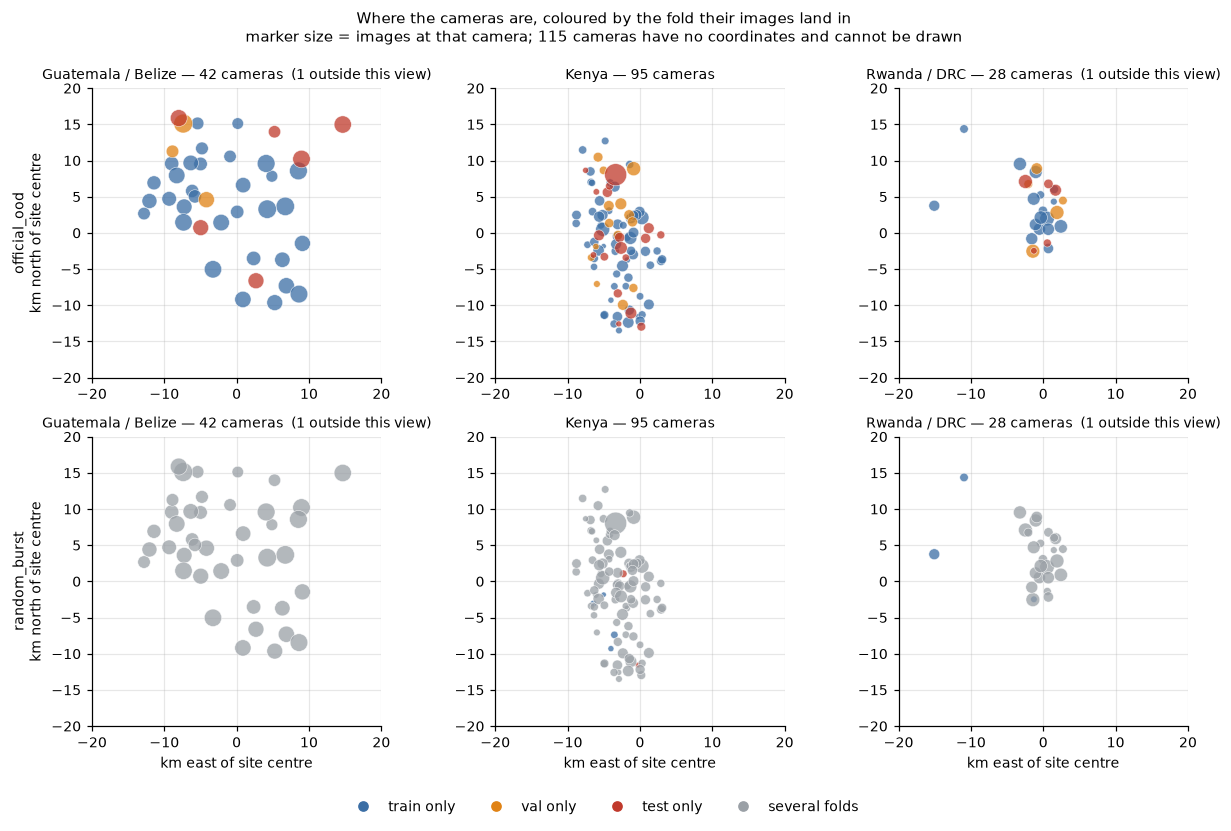

In [11]:
import json

from iwildcam.data import DATA

gps = {int(k): (v["latitude"], v["longitude"])
       for k, v in json.loads((DATA / "gps_locations.json").read_text()).items()}
n_img = task.df["location"].value_counts()
cams = task.cameras()
known = np.array([c for c in cams if c in gps])
withheld = np.array([c for c in cams if c not in gps])

print(f"cameras in the labelled task   {len(cams):3d}")
print(f"  coordinates released         {len(known):3d}   {n_img[known].sum():7,d} images "
      f"({n_img[known].sum() / len(task.df):5.1%}), median {n_img[known].median():3.0f} per camera")
print(f"  coordinates withheld         {len(withheld):3d}   {n_img[withheld].sum():7,d} images "
      f"({n_img[withheld].sum() / len(task.df):5.1%}), median {n_img[withheld].median():3.0f} per camera")


def where_used(split):
    """Which fold, or folds, each camera's images end up in."""
    fold = load_fold(task, split)
    seen = {}
    for name, idx in fold.items():
        for c in np.unique(task.camera[idx]):
            seen.setdefault(c, set()).add(name)
    return {c: (f"{next(iter(v))} only" if len(v) == 1 else "several folds")
            for c, v in seen.items()}


def km(a, b):
    """Great-circle distance in km between every point in `a` and every point in `b`."""
    (la1, lo1), (la2, lo2) = np.radians(a).T, np.radians(b).T
    h = (np.sin((la2[None, :] - la1[:, None]) / 2) ** 2
         + np.cos(la1)[:, None] * np.cos(la2)[None, :]
         * np.sin((lo2[None, :] - lo1[:, None]) / 2) ** 2)
    return 6371.0 * 2 * np.arcsin(np.sqrt(h))


ood = load_fold(task, "official_ood")
tr = [c for c in np.unique(task.camera[ood["train"]]) if c in gps]
te = [c for c in np.unique(task.camera[ood["test"]]) if c in gps]
nearest = km(np.array([gps[c] for c in te]), np.array([gps[c] for c in tr])).min(1)
print(f"\nof the {len(np.unique(task.camera[ood['test']]))} held-out cameras, {len(te)} have "
      f"coordinates. Distance from each of those")
print(f"to the nearest camera the model trains on: min {nearest.min():.2f} km, "
      f"median {np.median(nearest):.2f} km, max {nearest.max():.2f} km")
print(f"{(nearest <= 5).sum()} of {len(nearest)} are within 5 km.")

# Three sites hold nearly every located camera. Positions are drawn in km from the site
# centre, so each panel is a map at true scale.
SITES = {"Guatemala / Belize": (17.4, -89.3), "Kenya": (0.4, 36.9), "Rwanda / DRC": (-2.6, 29.4)}
VIEW = 20            # km shown either side of the centre
COLOUR = {"train only": "#3b6ea5", "val only": "#e08214", "test only": "#c0392b",
          "several folds": "#9aa0a6"}


def site_of(c):
    """The site a camera belongs to, or None if it is far from all three."""
    name, far = min(((n, np.hypot(gps[c][0] - a, gps[c][1] - b)) for n, (a, b) in SITES.items()),
                    key=lambda t: t[1])
    return name if far < 2.0 else None            # 2 degrees, about 200 km


splits = ["official_ood", "random_burst"]
fig, axes = plt.subplots(len(splits), len(SITES), figsize=(11.5, 7.5))
for r, split in enumerate(splits):
    role = where_used(split)
    for c, (site, (lat0, lon0)) in enumerate(SITES.items()):
        ax = axes[r, c]
        here = [k for k in known if site_of(k) == site]
        east = {k: (gps[k][1] - lon0) * 111.32 * np.cos(np.radians(lat0)) for k in here}
        north = {k: (gps[k][0] - lat0) * 110.57 for k in here}
        for label, colour in COLOUR.items():
            sel = [k for k in here if role[k] == label]
            if not sel:
                continue
            ax.scatter([east[k] for k in sel], [north[k] for k in sel],
                       s=8 + 2.2 * np.sqrt(n_img[sel].to_numpy()), c=colour, alpha=0.75,
                       edgecolors="white", linewidths=0.4, zorder=3)
        # A couple of cameras sit far outside their site. Keep the view on the cluster and
        # say how many fell off it, rather than squashing the map to fit them.
        far = sum(1 for k in here if abs(east[k]) > VIEW or abs(north[k]) > VIEW)
        ax.set_xlim(-VIEW, VIEW)
        ax.set_ylim(-VIEW, VIEW)
        ax.set_aspect("equal")
        ax.set_title(f"{site} — {len(here)} cameras"
                     + (f"  ({far} outside this view)" if far else ""), fontsize=9)
        if c == 0:
            ax.set_ylabel(f"{split}\nkm north of site centre")
        if r == len(splits) - 1:
            ax.set_xlabel("km east of site centre")

handles = [plt.Line2D([], [], marker="o", ls="", color=v, label=k) for k, v in COLOUR.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Where the cameras are, coloured by the fold their images land in\n"
             f"marker size = images at that camera; {len(withheld)} cameras have no "
             "coordinates and cannot be drawn", fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 0.99))

for split in splits:
    role = pd.Series(where_used(split))
    print(f"\n{split:13s} " + ",  ".join(f"{v} {k}" for k, v in role.value_counts().items()))
    print("  withheld, so absent from the map: " + ",  ".join(
        f"{v} {k}" for k, v in role[withheld].value_counts().items()))

**The top row is the whole argument for this project.** Red held-out cameras sit inside the
blue training cloud, a kilometre or two apart, in the same forest with the same species. The
model still loses a third of its macro F1 crossing that distance. 

**The bottom row is why `random_burst` is only a reference.** Almost every camera is grey:
its images are in train *and* val *and* test at once. That
is the in-distribution number, and the gap between the rows is what you are trying to close.

**Read the distances with the obfuscation in mind.** Released coordinates are generalised to
about a kilometre at the data providers' request, and the median held-out camera is roughly
that far from its nearest training camera. So the distances above are the right order of
magnitude and no more: "about a kilometre" means "the same neighbourhood", not a measurement
you can build on.

### The blank spaces on the map

**115 of the 294 cameras have no coordinates, and that is deliberate.** They were withheld by
the data providers as an anti-poaching measure: publishing the exact location of a camera
that photographs threatened wildlife tells a poacher where the animals are and where they
are being watched from. The competition readme states the unreleased locations are all from
one country and were held back at the request of the Wildlife Conservation Society. The
coordinates that *were* released are generalised to about a kilometre and published on an
18-month lag, for the same reason.


**And the missingness is not random, which makes it a trap.** Every camera whose dominant
species is Southeast Asian lacks coordinates; every camera outside that region has them. So
"does this camera have a GPS entry" is very nearly a region label. Feed the model
coordinates, or even an is-it-missing flag, and you have handed it exactly the shortcut this
project exists to remove. The withheld cameras are also small — a median of 13 images against
263 — so they are 39% of the cameras but only 2.5% of the images, which is why the map still
covers 97.5% of what you train on.

## One more thing

Below is the bottom 7% of seven training images, at the resolution the model is given.

What is in that strip, and what does a convolutional network do with it?

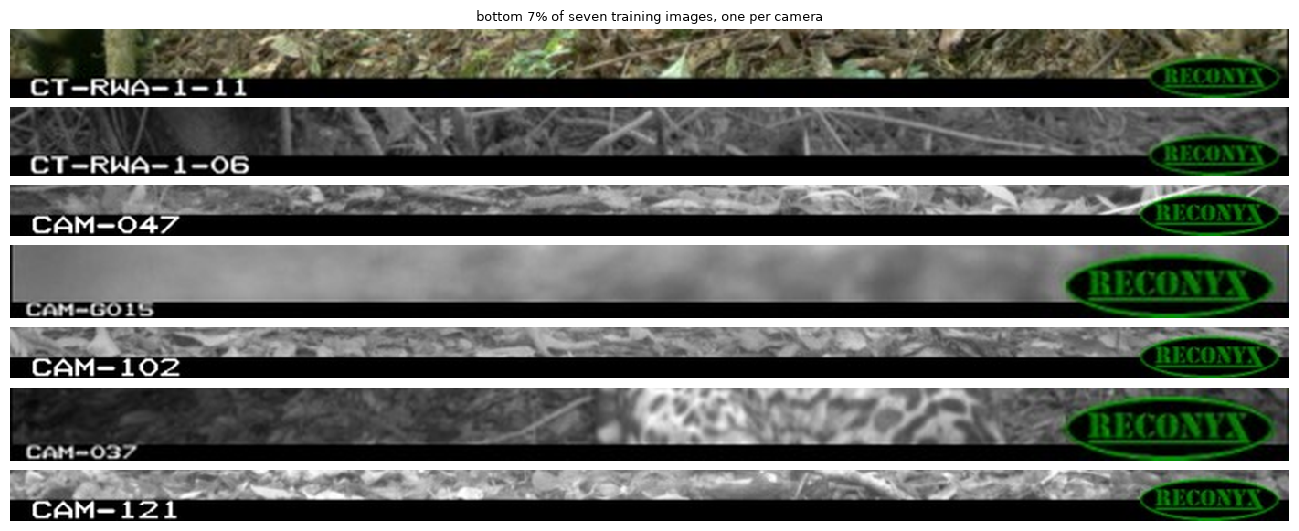

In [ ]:
STRIPS = [
    "959421cc-21bc-11ea-a13a-137349068a90.jpg",
    "8fd625aa-21bc-11ea-a13a-137349068a90.jpg",
    "8f160680-21bc-11ea-a13a-137349068a90.jpg",
    "8fa9fe1c-21bc-11ea-a13a-137349068a90.jpg",
    "9171d29c-21bc-11ea-a13a-137349068a90.jpg",
    "90dcbde2-21bc-11ea-a13a-137349068a90.jpg",
    "87e75152-21bc-11ea-a13a-137349068a90.jpg",
]
W, GAP = 1400, 10
tiles = []
for name in STRIPS:
    im = show(name).convert("RGB")
    strip = im.crop((0, int(im.height * 0.93), im.width, im.height))
    tiles.append(strip.resize((W, round(strip.height * W / strip.width)), Image.LANCZOS))

H = sum(t.height + GAP for t in tiles) - GAP
canvas = Image.new("RGB", (W, H), (255, 255, 255))
y = 0
for t in tiles:
    canvas.paste(t, (0, y))
    y += t.height + GAP

fig, ax = plt.subplots(figsize=(W / 100, H / 100), dpi=100)
ax.imshow(np.asarray(canvas), interpolation="nearest")
ax.set_axis_off()
ax.set_title("bottom 7% of seven training images, one per camera", fontsize=9)
plt.tight_layout()